# Grad-EM checkpoint diagnostics

CPU-only analysis of the raw E64/K8 diagnostic tensors. For each token and layer, `z` is the selected router logit and `v = <g, h_i>` pairs the incoming gradient at the combined MoE output with selected expert output `i`. The extraction uses the training-equivalent summed cross-entropy gradient scale.

The main object is `q_eta = softmax(z - eta * v)` on the **existing fixed Top-K support**. This does not model changes to which experts enter Top-K. Softmax ignores common shifts, so within-token differences and centered scales are more informative than global means. The notebook reports empirical summaries and does not select an optimal eta.

In [1]:
from pathlib import Path

ANALYSIS_DIR = Path(
    "/work/09652/pedakb/analysis/modded-nanogpt-moe/e64k8_diag250"
)
ETA_GRID = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]
TEMPORAL_ETAS = [1e-2, 3e-2, 1e-1, 3e-1]
REPRESENTATIVE_LAYERS = [0, 3, 6, 9, 11]
EPS = 1e-12
SAVE_DERIVED_CSV = False

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", 30)
torch.set_grad_enabled(False)

QUANTILES = torch.tensor([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
QUANTILE_NAMES = ["q01", "q05", "q25", "q50", "q75", "q95", "q99"]
SUMMARY_QUANTILES = torch.tensor([0.05, 0.25, 0.50, 0.75, 0.95])
SUMMARY_NAMES = ["p05", "p25", "median", "p75", "p95"]

In [3]:
def quantile_summary(values, prefix=""):
    values = values.float().reshape(-1)
    assert torch.isfinite(values).all(), f"non-finite values in {prefix}"
    quantiles = torch.quantile(values, SUMMARY_QUANTILES).tolist()
    return {f"{prefix}{name}": value for name, value in zip(SUMMARY_NAMES, quantiles)}


def heatmap(frame, value, title, *, eta=None, cmap="viridis", ax=None):
    selected = frame if eta is None else frame[np.isclose(frame["eta"], eta)]
    table = selected.pivot(index="layer", columns="step", values=value).sort_index()
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    image = ax.imshow(table.to_numpy(), aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(table.columns)), table.columns)
    ax.set_yticks(range(len(table.index)), table.index)
    ax.set_xlabel("completed updates")
    ax.set_ylabel("layer")
    ax.set_title(title)
    plt.colorbar(image, ax=ax, shrink=0.8)
    return ax


def assert_finite_frame(frame, name):
    numeric = frame.select_dtypes(include=[np.number]).to_numpy()
    assert np.isfinite(numeric).all(), f"non-finite derived values in {name}"

## 1. Dataset sanity checks

Discover every `step_*.pt`, sort by checkpoint metadata, load on CPU, and enforce one shared batch hash and tensor schema. No model code is imported or executed.

In [4]:
assert ANALYSIS_DIR.is_dir(), f"analysis directory not found: {ANALYSIS_DIR}"
manifest_path = ANALYSIS_DIR / "manifest.json"
assert manifest_path.is_file(), f"manifest not found: {manifest_path}"
manifest = json.loads(manifest_path.read_text())

loaded = []
for path in ANALYSIS_DIR.glob("step_*.pt"):
    payload = torch.load(path, map_location="cpu", weights_only=False)
    loaded.append((int(payload["completed_updates"]), path, payload))
loaded.sort(key=lambda item: item[0])
assert loaded, f"no step_*.pt files found under {ANALYSIS_DIR}"

reference_hash = loaded[0][2]["eval_batch_hash"]
reference_layers = sorted(loaded[0][2]["layers"])
reference_model = loaded[0][2]["model"]
E = int(reference_model["num_experts"])
K = int(reference_model["top_k"])
N = loaded[0][2]["layers"][reference_layers[0]]["selected_logits"].shape[0]
sanity_rows = []

for step, path, payload in loaded:
    layers = sorted(payload["layers"])
    assert payload["eval_batch_hash"] == reference_hash, f"batch hash mismatch at step {step}"
    assert layers == reference_layers, f"layer mismatch at step {step}"
    assert int(payload["model"]["top_k"]) == K, f"K mismatch at step {step}"
    assert int(payload["model"]["num_experts"]) == E, f"E mismatch at step {step}"
    for layer in layers:
        tensors = payload["layers"][layer]
        assert tensors["selected_logits"].shape == (N, K)
        assert tensors["v"].shape == (N, K)
        assert tensors["topk_experts"].shape == (N, K)
        assert tensors["router_logsumexp"].shape == (N,)
        assert all(torch.isfinite(tensors[name]).all() for name in ("selected_logits", "v", "router_logsumexp"))
        assert ((tensors["topk_experts"] >= 0) & (tensors["topk_experts"] < E)).all()
    sanity_rows.append({
        "step": step, "file": path.name, "layers": len(layers),
        "N": N, "K": K, "E": E, "eval_batch_hash": payload["eval_batch_hash"],
    })

manifest_hash = manifest.get("eval_batch_hash")
assert manifest_hash in (None, reference_hash), "manifest/result batch hash mismatch"
sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)
print(f"steps: {[step for step, _, _ in loaded]}")
print(f"layers: {len(reference_layers)}; N: {N}; K: {K}; E: {E}")
print(f"eval batch hash: {reference_hash}")

,step,file,layers,N,K,E,eval_batch_hash
0,50,step_000050.pt,12,65536,8,64,4db929a1aaaca7c06f0ad1d4fa177215251286af00a232...
1,100,step_000100.pt,12,65536,8,64,4db929a1aaaca7c06f0ad1d4fa177215251286af00a232...
2,150,step_000150.pt,12,65536,8,64,4db929a1aaaca7c06f0ad1d4fa177215251286af00a232...
3,200,step_000200.pt,12,65536,8,64,4db929a1aaaca7c06f0ad1d4fa177215251286af00a232...
4,250,step_000250.pt,12,65536,8,64,4db929a1aaaca7c06f0ad1d4fa177215251286af00a232...


steps: [50, 100, 150, 200, 250]
layers: 12; N: 65536; K: 8; E: 64
eval batch hash: 4db929a1aaaca7c06f0ad1d4fa177215251286af00a232aba0d3abe68d05f594


## 2. Raw `z` and `v` scale

Global means, standard deviations, and quantiles provide orientation. They are secondary: adding a token-specific constant across all K logits leaves the softmax unchanged.

,step,layer,z_mean,z_std,v_mean,v_std,z_q01,z_q05,z_q25,z_q50,z_q75,z_q95,z_q99,v_q01,v_q05,v_q25,v_q50,v_q75,v_q95,v_q99
0,50,0,2.428152,1.453511,0.006097,0.251566,0.867188,1.054688,1.445312,1.945312,2.953125,5.34375,8.18750,-0.752543,-0.365090,-0.087877,0.008236,0.106775,0.367727,0.704949
1,50,1,2.495947,1.456954,0.004274,0.220220,0.898438,1.117188,1.531250,2.015625,2.984375,5.56250,8.25000,-0.639408,-0.323049,-0.083741,0.006572,0.098062,0.321846,0.608905
2,50,2,2.524156,1.389074,0.004157,0.200774,1.039062,1.242188,1.640625,2.093750,2.906250,5.43750,7.68750,-0.573525,-0.288426,-0.077469,0.005508,0.089685,0.290079,0.549618
3,50,3,2.621383,1.418777,0.004151,0.194526,1.085938,1.312500,1.718750,2.171875,3.015625,5.59375,8.43750,-0.554299,-0.277729,-0.076606,0.005458,0.087904,0.281983,0.539934
4,50,4,2.770346,1.421032,0.004369,0.160814,1.234375,1.445312,1.851562,2.343750,3.218750,5.46875,8.81250,-0.444199,-0.227556,-0.064605,0.003752,0.073840,0.237544,0.452017
5,50,5,2.849748,1.444222,0.002032,0.163776,1.242188,1.460938,1.890625,2.390625,3.328125,5.84375,8.31250,-0.459290,-0.238429,-0.068316,0.001872,0.073632,0.242131,0.455604
6,50,6,2.935182,1.390372,0.001658,0.160965,1.296875,1.562500,2.015625,2.531250,3.421875,5.65625,8.00000,-0.454810,-0.235177,-0.067553,0.000936,0.072146,0.241807,0.444539
7,50,7,2.877578,1.420795,0.000613,0.162374,1.304688,1.546875,1.992188,2.484375,3.312500,5.40625,8.56250,-0.456525,-0.244446,-0.072331,-0.000917,0.073925,0.249659,0.453037
8,50,8,2.842022,1.282768,-0.000520,0.176147,1.289062,1.515625,1.960938,2.468750,3.328125,5.50000,7.31250,-0.499694,-0.268882,-0.080940,-0.001505,0.080279,0.272725,0.487749
9,50,9,3.012316,1.444865,-0.001499,0.198459,1.382812,1.625000,2.078125,2.593750,3.437500,6.03125,8.62500,-0.555350,-0.301845,-0.093811,-0.003843,0.089542,0.308682,0.554215


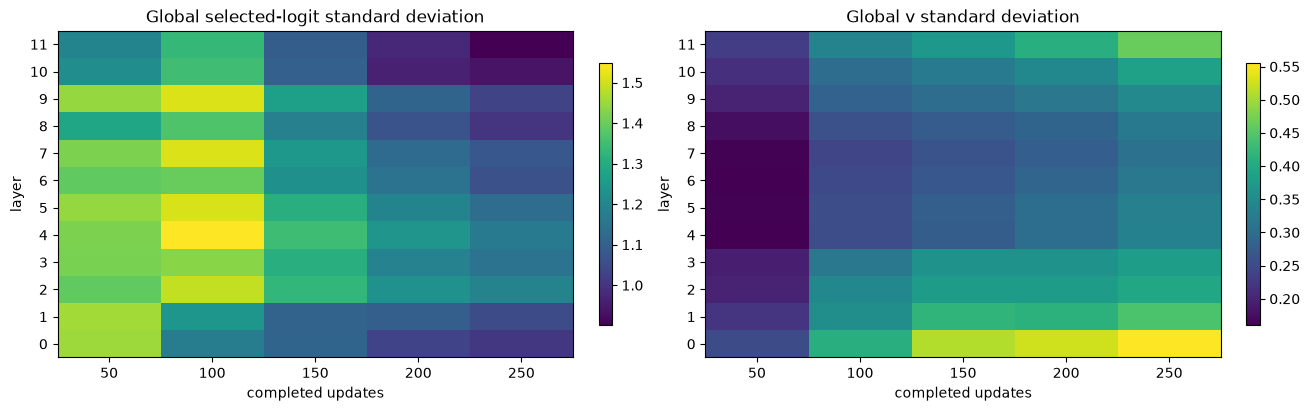

In [5]:
raw_rows = []
with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            z = payload["layers"][layer]["selected_logits"]
            v = payload["layers"][layer]["v"]
            row = {
                "step": step, "layer": layer,
                "z_mean": z.mean().item(), "z_std": z.std(unbiased=False).item(),
                "v_mean": v.mean().item(), "v_std": v.std(unbiased=False).item(),
            }
            for prefix, values in (("z", z), ("v", v)):
                for name, value in zip(QUANTILE_NAMES, torch.quantile(values.reshape(-1), QUANTILES).tolist()):
                    row[f"{prefix}_{name}"] = value
            raw_rows.append(row)
raw_df = pd.DataFrame(raw_rows)
assert_finite_frame(raw_df, "raw scale")
display(raw_df.head(12))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
heatmap(raw_df, "z_std", "Global selected-logit standard deviation", ax=axes[0])
heatmap(raw_df, "v_std", "Global v standard deviation", ax=axes[1])
plt.show()

## 3. Within-token centered scales

For each token, center `z` and `v` across its selected experts and measure population standard deviation (`unbiased=False`) and range. These are the primary scales because they describe differences that can affect a softmax.

,step,layer,sigma_z_p05,sigma_z_p25,sigma_z_median,sigma_z_p75,sigma_z_p95,sigma_v_p05,sigma_v_p25,sigma_v_median,sigma_v_p75,sigma_v_p95,range_z_p05,range_z_p25,range_z_median,range_z_p75,range_z_p95,range_v_p05,range_v_p25,range_v_median,range_v_p75,range_v_p95,sigma_v_over_sigma_z_p05,sigma_v_over_sigma_z_p25,sigma_v_over_sigma_z_median,sigma_v_over_sigma_z_p75,sigma_v_over_sigma_z_p95
0,50,0,0.367118,0.634218,0.956249,1.488168,2.295919,0.050210,0.098755,0.151303,0.224876,0.396592,1.101562,1.910156,2.898438,4.531250,7.812500,0.157611,0.315872,0.487363,0.732476,1.312161,0.034242,0.085488,0.158696,0.284261,0.621312
1,50,1,0.371688,0.638523,0.957036,1.513935,2.455648,0.047279,0.091288,0.136448,0.198367,0.342780,1.117188,1.929688,2.890625,4.710938,7.628906,0.149477,0.290082,0.436589,0.643376,1.123242,0.031939,0.077599,0.140581,0.248710,0.547682
2,50,2,0.369884,0.646501,0.978143,1.588079,2.356901,0.043020,0.082185,0.122680,0.181151,0.318143,1.125000,1.953125,2.960938,4.898438,6.984375,0.134989,0.260629,0.394059,0.589235,1.055170,0.029155,0.069835,0.125946,0.222297,0.481498
3,50,3,0.415140,0.728464,1.066436,1.546360,2.382829,0.042090,0.081241,0.120127,0.174032,0.311856,1.250000,2.210938,3.289062,4.734375,7.555664,0.132227,0.257794,0.384909,0.567295,1.033896,0.030238,0.066685,0.114733,0.194881,0.415044
4,50,4,0.406195,0.719426,1.076099,1.541407,2.371657,0.035414,0.067750,0.100150,0.146255,0.254766,1.218750,2.164062,3.218750,4.765625,7.632812,0.110444,0.214924,0.322092,0.477070,0.856634,0.025328,0.055382,0.094589,0.164059,0.355518
5,50,5,0.456560,0.792140,1.144814,1.571396,2.389840,0.035220,0.070547,0.104072,0.150225,0.257031,1.375000,2.390625,3.476562,4.812500,7.414062,0.111049,0.223700,0.334532,0.491070,0.866435,0.025439,0.055056,0.091530,0.153924,0.336040
6,50,6,0.473225,0.772286,1.086352,1.477320,2.339600,0.034513,0.068857,0.101441,0.145613,0.252794,1.429688,2.328125,3.304688,4.554688,7.421875,0.108305,0.219079,0.326436,0.476755,0.846246,0.027637,0.057832,0.092782,0.150266,0.311164
7,50,7,0.429531,0.730568,1.040214,1.426869,2.494736,0.034807,0.070356,0.104687,0.148987,0.248480,1.296875,2.210938,3.140625,4.421875,8.054688,0.110150,0.223151,0.335357,0.485762,0.827986,0.024840,0.058567,0.099242,0.167775,0.357740
8,50,8,0.477198,0.783045,1.078277,1.426803,1.945365,0.039076,0.079049,0.116532,0.165934,0.267275,1.437500,2.351562,3.250000,4.367188,6.095703,0.123123,0.250400,0.373999,0.537025,0.887898,0.030420,0.068014,0.110310,0.175691,0.350409
9,50,9,0.478922,0.798758,1.134779,1.604185,2.366442,0.040183,0.085090,0.125526,0.179582,0.294249,1.445312,2.406250,3.484375,5.015625,7.460938,0.125567,0.267932,0.401819,0.581190,0.978470,0.027105,0.066472,0.112233,0.182709,0.366052


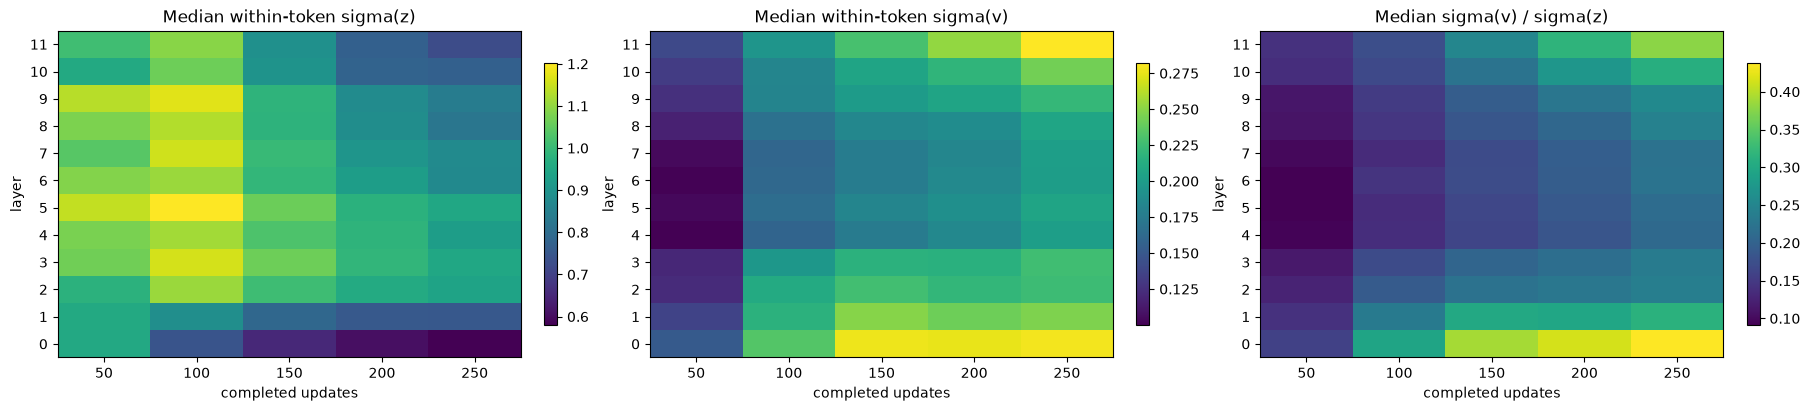

In [6]:
scale_rows = []
with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            z = payload["layers"][layer]["selected_logits"]
            v = payload["layers"][layer]["v"]
            z_centered = z - z.mean(dim=-1, keepdim=True)
            v_centered = v - v.mean(dim=-1, keepdim=True)
            sigma_z = z_centered.std(dim=-1, unbiased=False)
            sigma_v = v_centered.std(dim=-1, unbiased=False)
            range_z = z.max(dim=-1).values - z.min(dim=-1).values
            range_v = v.max(dim=-1).values - v.min(dim=-1).values
            ratio = sigma_v / (sigma_z + EPS)
            row = {"step": step, "layer": layer}
            for name, values in (("sigma_z", sigma_z), ("sigma_v", sigma_v),
                                 ("range_z", range_z), ("range_v", range_v),
                                 ("sigma_v_over_sigma_z", ratio)):
                row.update(quantile_summary(values, f"{name}_"))
            scale_rows.append(row)
scale_df = pd.DataFrame(scale_rows)
assert_finite_frame(scale_df, "within-token scale")
display(scale_df.head(12))
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
heatmap(scale_df, "sigma_z_median", "Median within-token sigma(z)", ax=axes[0])
heatmap(scale_df, "sigma_v_median", "Median within-token sigma(v)", ax=axes[1])
heatmap(scale_df, "sigma_v_over_sigma_z_median", "Median sigma(v) / sigma(z)", ax=axes[2])
plt.show()

## 4. Eta-relative scale

`r_eta = eta * sigma_v / (sigma_z + eps)` compares the within-support Grad-EM perturbation scale to router-logit variation. Values much less than 1 indicate a small perturbation, values near 1 indicate comparable scales, and values much greater than 1 indicate that the correction dominates the selected-logit variation.

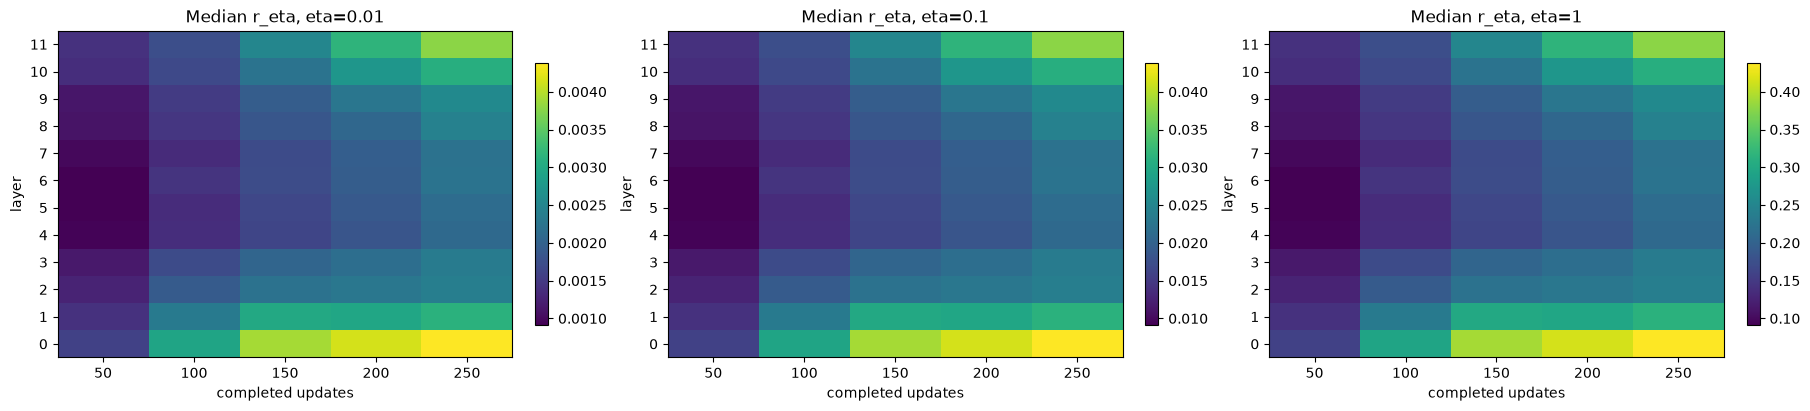

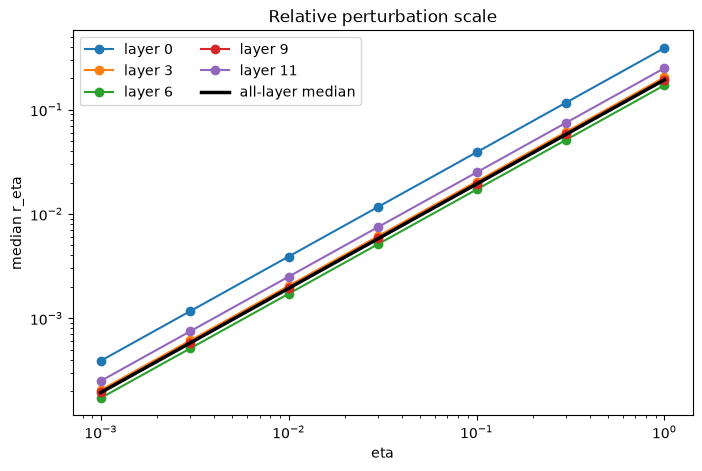

In [7]:
r_rows = []
with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            z = payload["layers"][layer]["selected_logits"]
            v = payload["layers"][layer]["v"]
            sigma_z = z.std(dim=-1, unbiased=False)
            sigma_v = v.std(dim=-1, unbiased=False)
            base_ratio = sigma_v / (sigma_z + EPS)
            for eta in ETA_GRID:
                row = {"step": step, "layer": layer, "eta": eta}
                row.update(quantile_summary(eta * base_ratio, "r_"))
                r_rows.append(row)
r_df = pd.DataFrame(r_rows)
assert_finite_frame(r_df, "eta-relative scale")
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
for ax, eta in zip(axes, [1e-2, 1e-1, 1.0]):
    heatmap(r_df, "r_median", f"Median r_eta, eta={eta:g}", eta=eta, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
representative = r_df[r_df["layer"].isin(REPRESENTATIVE_LAYERS)]
for layer, group in representative.groupby("layer"):
    curve = group.groupby("eta")["r_median"].median()
    ax.plot(curve.index, curve.values, marker="o", label=f"layer {layer}")
aggregate = r_df.groupby("eta")["r_median"].median()
ax.plot(aggregate.index, aggregate.values, color="black", linewidth=2.5, label="all-layer median")
ax.set(xscale="log", yscale="log", xlabel="eta", ylabel="median r_eta", title="Relative perturbation scale")
ax.legend(ncol=2)
plt.show()

## 5. Original Top-K routing weights

`a = softmax(z)` is the normalized forward distribution within Top-K. In contrast, `p_selected = exp(z - router_logsumexp)` reconstructs the full E=64 router probability of each selected expert, and `topk_mass` is their total full-router mass.

observed topk_mass range: [0.23142114, 0.99999392]


,step,layer,entropy_p05,entropy_p25,entropy_median,entropy_p75,entropy_p95,max_a_p05,max_a_p25,max_a_median,max_a_p75,max_a_p95,min_a_p05,min_a_p25,min_a_median,min_a_p75,min_a_p95,topk_mass_p05,topk_mass_p25,topk_mass_median,topk_mass_p75,topk_mass_p95
0,50,0,0.249899,0.984637,1.535587,1.852128,2.007747,0.211605,0.316038,0.477652,0.734475,0.951733,0.000379,0.007042,0.026465,0.048242,0.074813,0.429714,0.566261,0.709663,0.903074,0.993288
1,50,1,0.279195,0.905168,1.528086,1.846292,2.006076,0.213850,0.319243,0.489670,0.751144,0.947658,0.000402,0.006794,0.026793,0.048204,0.074258,0.450011,0.587066,0.724507,0.900589,0.993333
2,50,2,0.195528,0.811349,1.502779,1.839942,2.005936,0.213567,0.325872,0.493429,0.764659,0.966045,0.000775,0.005828,0.025571,0.047629,0.074260,0.478563,0.601076,0.739691,0.924989,0.987670
3,50,3,0.075016,0.810818,1.394250,1.771231,1.987396,0.227363,0.355876,0.544171,0.799053,0.989658,0.000508,0.006445,0.020891,0.041284,0.068847,0.507771,0.647262,0.785471,0.920105,0.992957
4,50,4,0.103122,0.744675,1.444715,1.793472,1.992548,0.221936,0.338809,0.512853,0.816147,0.984491,0.000475,0.006687,0.020097,0.040937,0.069768,0.509905,0.664016,0.799993,0.919719,0.994523
5,50,5,0.166844,0.734592,1.318807,1.728491,1.970562,0.234313,0.372728,0.568805,0.820136,0.972557,0.000566,0.006317,0.017555,0.035792,0.064042,0.554420,0.701747,0.825558,0.925628,0.992681
6,50,6,0.119679,0.825918,1.388774,1.751169,1.962251,0.237816,0.364989,0.540449,0.794250,0.980991,0.000579,0.007703,0.019765,0.036947,0.062213,0.568843,0.700790,0.815451,0.914862,0.994242
7,50,7,0.056123,0.862932,1.465477,1.784159,1.983591,0.226406,0.346090,0.508559,0.785363,0.992556,0.000314,0.008791,0.021639,0.039814,0.066520,0.560142,0.694705,0.803512,0.907400,0.996472
8,50,8,0.255602,0.920856,1.422757,1.744224,1.959893,0.239347,0.362064,0.521177,0.751719,0.955033,0.002071,0.009010,0.020059,0.036037,0.061497,0.589754,0.717422,0.816813,0.907754,0.976121
9,50,9,0.108306,0.629953,1.306870,1.727322,1.960735,0.238425,0.376006,0.586142,0.856815,0.983572,0.000554,0.005463,0.017594,0.034944,0.061218,0.599545,0.735478,0.844084,0.943872,0.994127


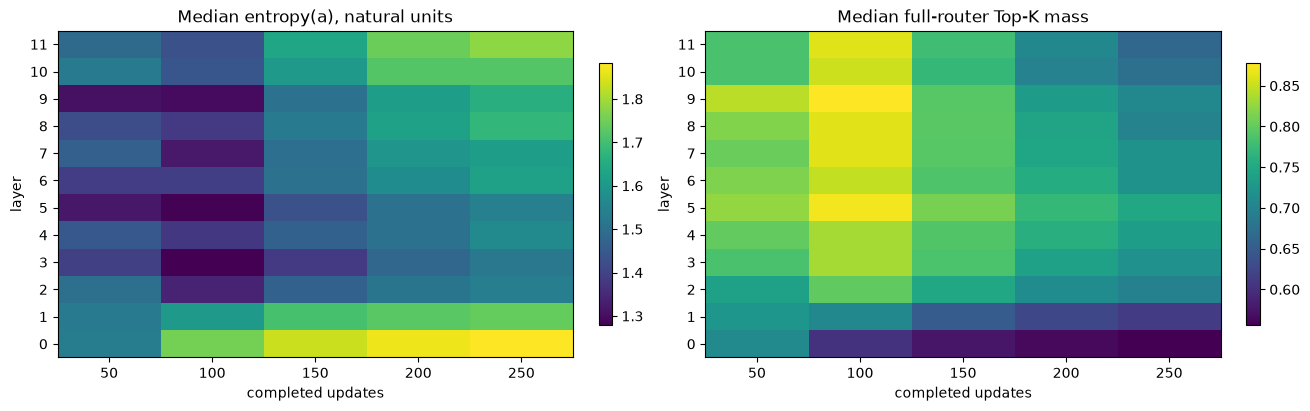

In [8]:
routing_rows = []
mass_min, mass_max = float("inf"), float("-inf")
with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            tensors = payload["layers"][layer]
            z = tensors["selected_logits"]
            log_a = torch.log_softmax(z, dim=-1)
            a = log_a.exp()
            entropy = -(a * log_a).sum(dim=-1)
            maximum = a.max(dim=-1).values
            minimum = a.min(dim=-1).values
            p_selected = torch.exp(z - tensors["router_logsumexp"][:, None])
            topk_mass = p_selected.sum(dim=-1)
            mass_min = min(mass_min, topk_mass.min().item())
            mass_max = max(mass_max, topk_mass.max().item())
            row = {"step": step, "layer": layer}
            for name, values in (("entropy", entropy), ("max_a", maximum),
                                 ("min_a", minimum), ("topk_mass", topk_mass)):
                row.update(quantile_summary(values, f"{name}_"))
            routing_rows.append(row)
routing_df = pd.DataFrame(routing_rows)
assert_finite_frame(routing_df, "routing")
assert mass_min >= -1e-6 and mass_max <= 1 + 1e-5, (mass_min, mass_max)
print(f"observed topk_mass range: [{mass_min:.8f}, {mass_max:.8f}]")
display(routing_df.head(12))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
heatmap(routing_df, "entropy_median", "Median entropy(a), natural units", ax=axes[0])
heatmap(routing_df, "topk_mass_median", "Median full-router Top-K mass", ax=axes[1])
plt.show()

## 6. Eta sweep: `q_eta` versus `a`

For fixed support, `q_eta = softmax(z - eta*v)`. Total variation and L1 measure distribution movement, `KL(q_eta || a)` measures directed divergence, maximum coordinate change reports the largest weight movement, and argmax-change fraction measures changes to the most-weighted expert **within the existing support**. It is not a hard-support change rate.

In [9]:
eta_rows = []
tv_min, tv_max = float("inf"), float("-inf")
with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            z = payload["layers"][layer]["selected_logits"]
            v = payload["layers"][layer]["v"]
            log_a = torch.log_softmax(z, dim=-1)
            a = log_a.exp()
            sigma_z = z.std(dim=-1, unbiased=False)
            sigma_v = v.std(dim=-1, unbiased=False)
            base_ratio = sigma_v / (sigma_z + EPS)
            argmax_a = a.argmax(dim=-1)
            for eta in ETA_GRID:
                log_q = torch.log_softmax(z - eta * v, dim=-1)
                q = log_q.exp()
                delta = (q - a).abs()
                tv = 0.5 * delta.sum(dim=-1)
                kl = (q * (log_q - log_a)).sum(dim=-1)
                max_abs_delta = delta.max(dim=-1).values
                l1_delta = delta.sum(dim=-1)
                changed = (argmax_a != q.argmax(dim=-1)).float()
                r_eta = eta * base_ratio
                assert all(torch.isfinite(metric).all() for metric in (tv, kl, max_abs_delta, l1_delta, r_eta))
                tv_min, tv_max = min(tv_min, tv.min().item()), max(tv_max, tv.max().item())
                row = {
                    "step": step, "layer": layer, "eta": eta,
                    "median_tv": tv.median().item(), "mean_tv": tv.mean().item(),
                    "median_kl": kl.median().item(), "mean_kl": kl.mean().item(),
                    "median_max_abs_delta": max_abs_delta.median().item(),
                    "median_l1_delta": l1_delta.median().item(),
                    "argmax_change_fraction": changed.mean().item(),
                    "median_r": r_eta.median().item(),
                }
                eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows)
assert_finite_frame(eta_df, "eta sweep")
assert tv_min >= -1e-6 and tv_max <= 1 + 1e-6, (tv_min, tv_max)
assert eta_df["argmax_change_fraction"].between(0, 1).all()
display(eta_df.head(14))
print(f"observed TV range: [{tv_min:.8f}, {tv_max:.8f}]")

,step,layer,eta,median_tv,mean_tv,median_kl,mean_kl,median_max_abs_delta,median_l1_delta,argmax_change_fraction,median_r
0,50,0,0.001,0.000037,0.000048,1.341141e-08,1.484255e-08,0.000026,0.000075,0.003387,0.000159
1,50,0,0.003,0.000112,0.000145,7.161316e-08,1.234943e-07,0.000078,0.000224,0.003387,0.000476
2,50,0,0.010,0.000374,0.000482,5.371694e-07,1.361763e-06,0.000260,0.000748,0.003418,0.001587
3,50,0,0.030,0.001122,0.001446,4.797563e-06,1.225026e-05,0.000780,0.002245,0.003876,0.004761
4,50,0,0.100,0.003743,0.004821,5.326199e-05,1.363937e-04,0.002604,0.007486,0.008789,0.015870
5,50,0,0.300,0.011220,0.014479,4.797971e-04,1.239137e-03,0.007808,0.022439,0.024719,0.047609
6,50,0,1.000,0.037413,0.048448,5.348432e-03,1.412783e-02,0.026133,0.074825,0.082230,0.158695
7,50,1,0.001,0.000033,0.000042,1.111948e-08,1.233009e-08,0.000023,0.000066,0.003281,0.000141
8,50,1,0.003,0.000100,0.000127,6.042501e-08,9.665914e-08,0.000069,0.000199,0.003296,0.000422
9,50,1,0.010,0.000332,0.000423,4.323156e-07,1.054371e-06,0.000232,0.000664,0.003311,0.001406


observed TV range: [0.00000000, 0.99451339]


## 7. Compact eta-sweep views

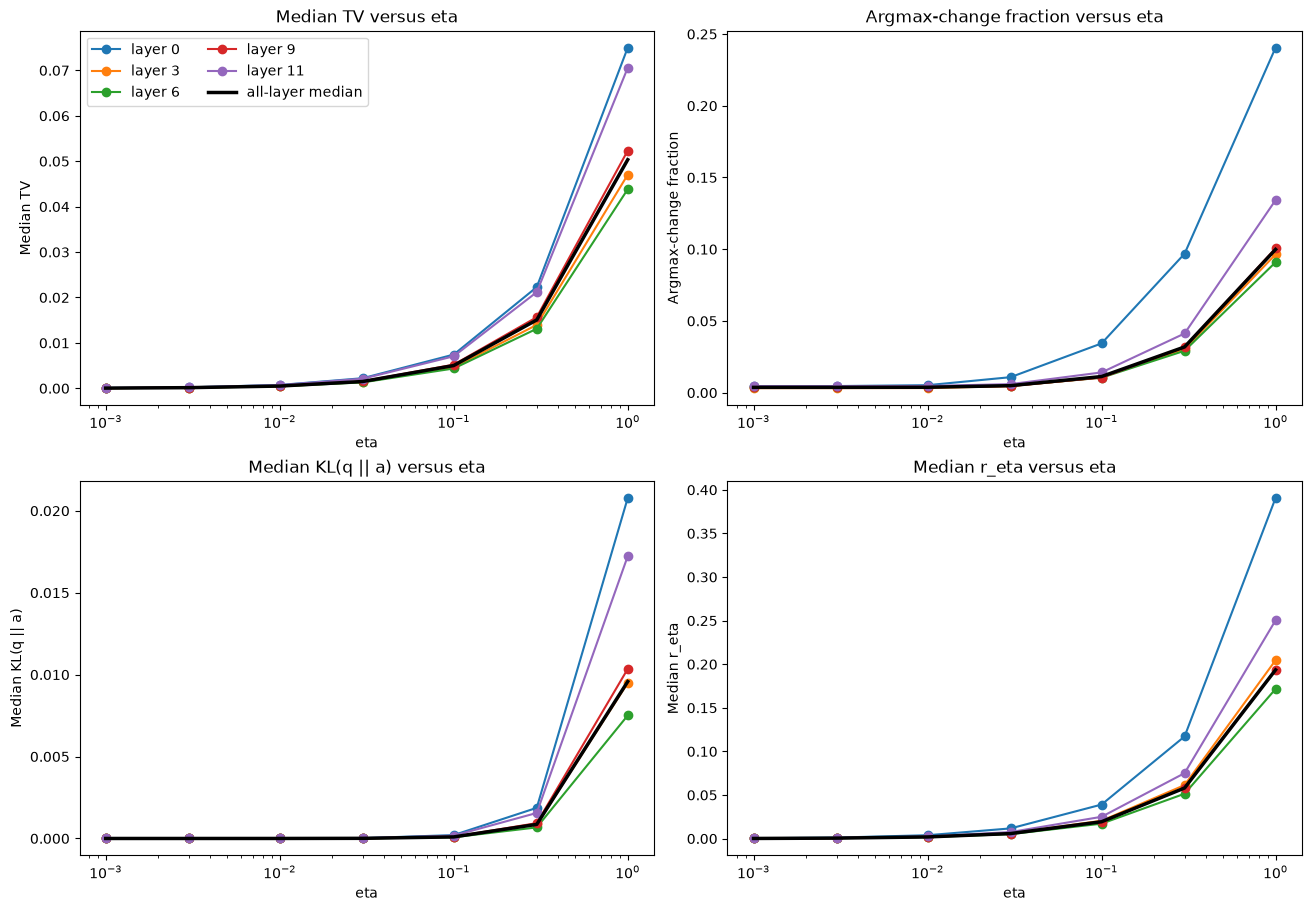

In [10]:
plot_metrics = [
    ("median_tv", "Median TV"),
    ("argmax_change_fraction", "Argmax-change fraction"),
    ("median_kl", "Median KL(q || a)"),
    ("median_r", "Median r_eta"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, (metric, label) in zip(axes.flat, plot_metrics):
    for layer in REPRESENTATIVE_LAYERS:
        curve = eta_df[eta_df["layer"] == layer].groupby("eta")[metric].median()
        ax.plot(curve.index, curve.values, marker="o", label=f"layer {layer}")
    aggregate = eta_df.groupby("eta")[metric].median()
    ax.plot(aggregate.index, aggregate.values, color="black", linewidth=2.5, label="all-layer median")
    ax.set_xscale("log")
    ax.set_xlabel("eta")
    ax.set_ylabel(label)
    ax.set_title(label + " versus eta")
axes[0, 0].legend(ncol=2)
plt.show()

## 8. Evolution across early training

These views compare the five checkpoints without assuming that eta should be constant or should change. Lines aggregate layer-level summaries by their median; the underlying layer-level tables remain available.

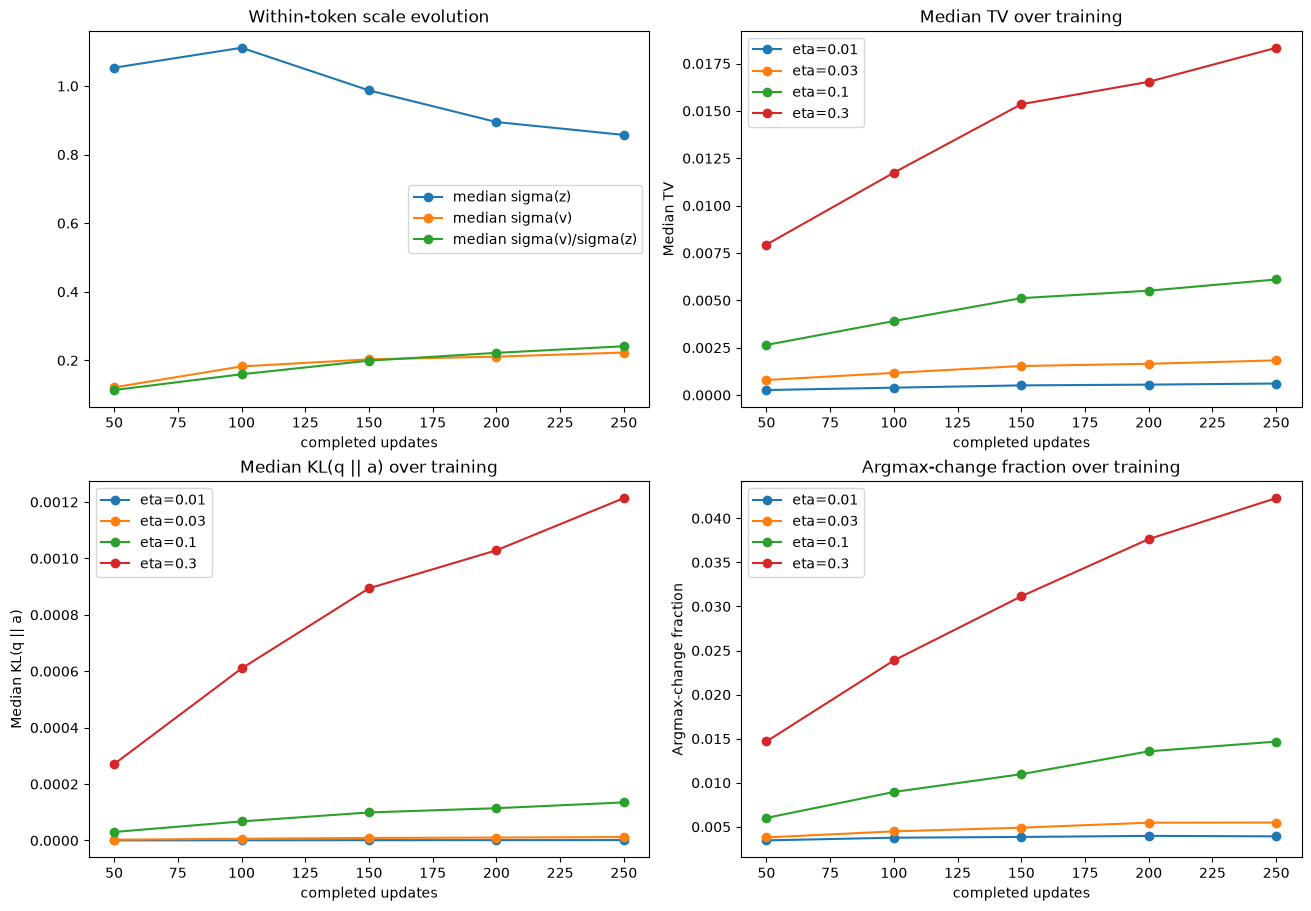

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
scale_time = scale_df.groupby("step")[["sigma_z_median", "sigma_v_median", "sigma_v_over_sigma_z_median"]].median()
for name, label in (("sigma_z_median", "median sigma(z)"),
                    ("sigma_v_median", "median sigma(v)"),
                    ("sigma_v_over_sigma_z_median", "median sigma(v)/sigma(z)")):
    axes[0, 0].plot(scale_time.index, scale_time[name], marker="o", label=label)
axes[0, 0].set(title="Within-token scale evolution", xlabel="completed updates")
axes[0, 0].legend()
for ax, metric, title in zip(axes.flat[1:], ["median_tv", "median_kl", "argmax_change_fraction"],
                             ["Median TV", "Median KL(q || a)", "Argmax-change fraction"]):
    subset = eta_df[eta_df["eta"].isin(TEMPORAL_ETAS)]
    for eta, group in subset.groupby("eta"):
        curve = group.groupby("step")[metric].median()
        ax.plot(curve.index, curve.values, marker="o", label=f"eta={eta:g}")
    ax.set(title=title + " over training", xlabel="completed updates", ylabel=title)
    ax.legend()
plt.show()

## 9. Lightweight expert-specific diagnostics

Selection frequency is normalized over all `N*K` assignments in a layer. Mean and median `v` are conditioned on an expert being selected. This is a screening view for obvious imbalance or extreme expert-conditioned values, not a causal expert-quality analysis.

In [ ]:
expert_rows = []

with torch.no_grad():
    for step, _, payload in loaded:
        for layer in reference_layers:
            expert_ids = (
                payload["layers"][layer]["topk_experts"]
                .reshape(-1)
                .to(torch.int64)
            )
            values = payload["layers"][layer]["v"].reshape(-1)

            counts = torch.bincount(expert_ids, minlength=E)

            sums = torch.zeros(E, dtype=torch.float64)
            sums.scatter_add_(
                0,
                expert_ids,
                values.to(torch.float64),
            )

            order = torch.argsort(expert_ids, stable=True)
            sorted_values = values[order]

            offsets = torch.cat([
                torch.zeros(1, dtype=torch.int64),
                counts.cumsum(0),
            ])

            for expert in range(E):
                count = int(counts[expert])

                if count > 0:
                    segment = sorted_values[
                        offsets[expert]:offsets[expert + 1]
                    ]

                    mean_v = (sums[expert] / count).item()
                    median_v = segment.median().item()
                else:
                    mean_v = float("nan")
                    median_v = float("nan")

                expert_rows.append({
                    "step": step,
                    "layer": layer,
                    "expert": expert,
                    "count": count,

                    # Fraction of all Top-K assignment slots
                    # assigned to this expert.
                    "assignment_fraction": (
                        count / expert_ids.numel()
                    ),

                    # Conditional statistics: only defined
                    # when the expert was selected at least once.
                    "mean_v_when_selected": mean_v,
                    "median_v_when_selected": median_v,
                })

expert_df = pd.DataFrame(expert_rows)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert np.isfinite(expert_df["assignment_fraction"]).all()
assert (expert_df["assignment_fraction"] >= 0).all()
assert (expert_df["assignment_fraction"] <= 1).all()

selected_mask = expert_df["count"] > 0

assert np.isfinite(
    expert_df.loc[selected_mask, "mean_v_when_selected"]
).all()

assert np.isfinite(
    expert_df.loc[selected_mask, "median_v_when_selected"]
).all()

# For every step/layer, assignment fractions should sum to 1.
assignment_sums = (
    expert_df
    .groupby(["step", "layer"])["assignment_fraction"]
    .sum()
)

assert np.allclose(
    assignment_sums.to_numpy(),
    1.0,
    atol=1e-6,
)

# ------------------------------------------------------------
# Report experts that received zero assignments
# ------------------------------------------------------------

unused_experts = (
    expert_df.loc[
        expert_df["count"] == 0,
        ["step", "layer", "expert"],
    ]
    .sort_values(["step", "layer", "expert"])
    .reset_index(drop=True)
)

print(f"Number of zero-assignment expert instances: {len(unused_experts)}")

if len(unused_experts):
    display(unused_experts)
else:
    print("Every expert was selected at least once for every step/layer.")

# ------------------------------------------------------------
# Plot latest checkpoint
# ------------------------------------------------------------

latest_step = sanity_df["step"].max()

latest = expert_df[
    expert_df["step"] == latest_step
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    constrained_layout=True,
)

plot_specs = [
    (
        "assignment_fraction",
        "Top-K assignment fraction",
    ),
    (
        "mean_v_when_selected",
        "Mean v when selected",
    ),
]

for ax, (metric, title) in zip(axes, plot_specs):
    table = (
        latest
        .pivot(
            index="layer",
            columns="expert",
            values=metric,
        )
        .sort_index()
    )

    image = ax.imshow(
        table.to_numpy(),
        aspect="auto",
        origin="lower",
    )

    ax.set(
        title=f"{title}, step {latest_step}",
        xlabel="expert",
        ylabel="layer",
    )

    ax.set_yticks(
        range(len(table.index)),
        table.index,
    )

    plt.colorbar(
        image,
        ax=ax,
        shrink=0.8,
    )

plt.show()

## 10. Compact summary tables and optional export

The tables retain step/layer resolution for inspection alongside the aggregate plots. Set `SAVE_DERIVED_CSV = True` in the configuration cell to write only derived CSV files under `ANALYSIS_DIR/derived`; raw `.pt` files are never modified.

In [ ]:
scale_summary = scale_df[[
    "step", "layer", "sigma_z_median", "sigma_v_median",
    "sigma_v_over_sigma_z_median",
]].merge(
    routing_df[["step", "layer", "topk_mass_median"]],
    on=["step", "layer"], validate="one_to_one",
).rename(columns={
    "sigma_z_median": "median_sigma_z",
    "sigma_v_median": "median_sigma_v",
    "sigma_v_over_sigma_z_median": "median_sigma_v_over_sigma_z",
    "topk_mass_median": "median_topk_mass",
})
eta_summary = eta_df[[
    "step", "layer", "eta", "median_r", "median_tv",
    "median_kl", "argmax_change_fraction",
]].copy()
assert_finite_frame(scale_summary, "scale summary")
assert_finite_frame(eta_summary, "eta summary")
display(scale_summary)
display(eta_summary)

if SAVE_DERIVED_CSV:
    derived_dir = ANALYSIS_DIR / "derived"
    derived_dir.mkdir(parents=True, exist_ok=True)
    scale_summary.to_csv(derived_dir / "scale_summary.csv", index=False)
    eta_summary.to_csv(derived_dir / "eta_summary.csv", index=False)
    expert_df.to_csv(derived_dir / "expert_summary.csv", index=False)
    print(f"saved derived CSV files under {derived_dir}")
else:
    print("SAVE_DERIVED_CSV=False; no files written")

## Interpretation caveats

- This analysis changes weights only within the already selected K=8 experts. It does not estimate support changes that a different routing procedure might make.
- Eta is meaningful only relative to the exact scale of `v`; these tensors use the extractor's training-equivalent summed cross-entropy gradient, with no token or accumulation-count division.
- TV, KL, and argmax changes describe `q_eta` relative to the original normalized Top-K weights `a`; they do not directly establish downstream optimization quality.
- The five checkpoints cover only the early trajectory. The notebook deliberately presents evidence without choosing an optimal eta.